# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">Import library</p>

In [1]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow import keras
from matplotlib import pyplot as plt
import pickle
import joblib
import pandas as pd
import numpy as np

# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">data_loading</p>

In [2]:
DATA_DIR = "./data/processed"

df_train = pd.read_csv(f"{DATA_DIR}/train.csv")
df_valid = pd.read_csv(f"{DATA_DIR}/valid.csv")

feature = [x for x in df_train.columns if x not in ['Id', 'SalePrice']]
target = 'SalePrice'

x_train = df_train[feature]
y_train = df_train[target]
x_valid = df_valid[feature]
y_valid = df_valid[target]

In [3]:
y_valid

0      154500
1      325000
2      115000
3      159000
4      315500
        ...  
287     89471
288    260000
289    189000
290    108000
291    124500
Name: SalePrice, Length: 292, dtype: int64

In [4]:
model = {
    "Support Vector Machine" : joblib.load("model/svr_model.pkl"),
    "XGBoost"                : joblib.load("model/xgb_model.pkl"),
    "Random Forest"          : joblib.load("model/rf_model.pkl")
}

svr_val_pred = model["Support Vector Machine"].predict(x_valid)
xgb_val_pred = model["XGBoost"].predict(x_valid)
rf_val_pred  = model["Random Forest"].predict(x_valid)

svr_rmse = np.sqrt(mean_squared_error(np.log(y_valid), np.log(svr_val_pred)))
xgb_rmse = np.sqrt(mean_squared_error(np.log(y_valid), np.log(xgb_val_pred)))
rf_rmse = np.sqrt(mean_squared_error(np.log(y_valid), np.log(rf_val_pred)))

output = {
    "Support Vector Machine"  : {"train" : svr_rmse, 
                                 "test"  : 0.41609},
    "XGBoost"        : {"train" : xgb_rmse, 
                        "test"  : 0.13620},
    "Random Forest" : {"train" : rf_rmse, 
                        "test"  : 0.15031}
}

d:\Repositories\SGU_machine_learning_TEAM\.venv\lib\site-packages\xgboost\core.py:158: UserWarning: [22:10:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


In [5]:
output

{'Support Vector Machine': {'train': 0.432059032673627, 'test': 0.41609},
 'XGBoost': {'train': 0.13212610437293565, 'test': 0.1362},
 'Random Forest': {'train': 0.15305979080231444, 'test': 0.15031}}

# <div style="color:white;display:fill;border-radius:5px;background-color:green;letter-spacing:0.1px;overflow:hidden"><p style="padding:20px;color:white;overflow:hidden;margin:0;font-size:100%;text-align:center">model_evaluation</p>

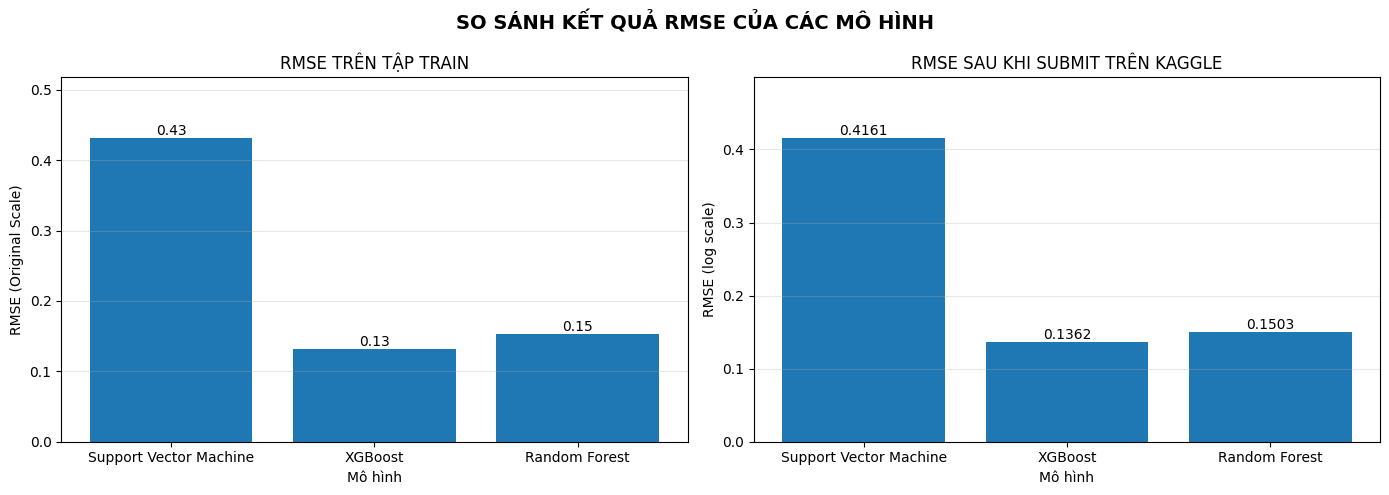

In [6]:
# ============================================================
# THỨ TỰ MÔ HÌNH CỐ ĐỊNH
# ============================================================

model_order = [
    "Support Vector Machine",
    "XGBoost",
    "Random Forest"
]


# ============================================================
# TỰ ĐỘNG TẠO RMSE_TRAIN TỪ BIẾN OUTPUT CỦA BẠN
# ============================================================

# Sử dụng trực tiếp biến output để tạo dataframe cho tập Train
rmse_train = pd.DataFrame({
    "Model": list(output.keys()),
    "Train RMSE": [output[model]['train'] for model in output.keys()]
})

rmse_train["Model"] = pd.Categorical(
    rmse_train["Model"],
    categories=model_order,
    ordered=True
)

rmse_train = (
    rmse_train
    .sort_values("Model")
    .reset_index(drop=True)
)


# ============================================================
# KẾT QUẢ KAGGLE (CŨNG LẤY TỪ BIẾN OUTPUT CỦA BẠN)
# ============================================================

# rmse_kaggle = pd.DataFrame({
#     "Model": model_order,
#     "Kaggle RMSE": [output[model]['test'] for model in model_order]
# })
rmse_kaggle = pd.DataFrame({
    "Model": model_order,
    "Kaggle RMSE": [
        0.41609,  # Support Vector Machine
        0.13620,  # XGBoost
        0.15031   # Random Forest
    ]
})

# ============================================================
# VẼ 2 BIỂU ĐỒ CẠNH NHAU
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# BIỂU ĐỒ 1: TRAIN RMSE
# ------------------------------------------------------------

bars1 = axes[0].bar(
    rmse_train["Model"].astype(str),
    rmse_train["Train RMSE"]
)

axes[0].set_title("RMSE TRÊN TẬP TRAIN")
axes[0].set_xlabel("Mô hình")
axes[0].set_ylabel("RMSE (Original Scale)")  # Đổi nhãn này vì tập train của bạn đang là giá gốc tuyệt đối
axes[0].grid(axis="y", alpha=0.3)

# Tạo khoảng trống phía trên cột cao nhất
max_train = rmse_train["Train RMSE"].max()

axes[0].set_ylim(
    0,
    max_train * 1.20
)

# Hiển thị số liệu 2 chữ số thập phân và thêm dấu phẩy hàng ngàn cho dễ đọc số lớn
for bar, value in zip(
    bars1,
    rmse_train["Train RMSE"]
):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.2f}",
        ha="center",
        va="bottom"
    )


# ------------------------------------------------------------
# BIỂU ĐỒ 2: KAGGLE RMSE
# ------------------------------------------------------------

bars2 = axes[1].bar(
    rmse_kaggle["Model"],
    rmse_kaggle["Kaggle RMSE"]
)

axes[1].set_title(
    "RMSE SAU KHI SUBMIT TRÊN KAGGLE"
)

axes[1].set_xlabel("Mô hình")
axes[1].set_ylabel("RMSE (log scale)")
axes[1].grid(axis="y", alpha=0.3)

# Tạo khoảng trống phía trên cột cao nhất
max_kaggle = rmse_kaggle["Kaggle RMSE"].max()

axes[1].set_ylim(
    0,
    max_kaggle * 1.20
)

# Hiển thị số liệu 4 chữ số thập phân
for bar, value in zip(
    bars2,
    rmse_kaggle["Kaggle RMSE"]
):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )


# ============================================================
# TIÊU ĐỀ CHUNG
# ============================================================

plt.suptitle(
    "SO SÁNH KẾT QUẢ RMSE CỦA CÁC MÔ HÌNH",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("model/rmse_comparison.png", dpi=300)
plt.show()